<a href="https://colab.research.google.com/github/Hemant10HM/ANNDL-LAB_24mcs004/blob/main/ANN_LAB_6_GradCAM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#GradCAM on CNN


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import os
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, random_split
from torchvision import transforms
from PIL import Image

import cv2
from tqdm import tqdm


In [12]:
# Define dataset path
dataset_path = "/content/drive/MyDrive/data/Pistachio_Image_Dataset"

# Define image transformations
transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.125, 0.125, 0.125])
])

# Define custom dataset class
class CustomPistatchioDataset(Dataset):
    def __init__(self, root_dir, transform=None):
        self.root_dir = root_dir
        self.transform = transform
        self.images = []
        self.labels = []
        self.class_names = sorted(os.listdir(root_dir))
        self.class_to_idx = {cls: idx for idx, cls in enumerate(self.class_names)}

        for cls in self.class_names:
            class_path = os.path.join(root_dir, cls)
            if os.path.isdir(class_path):
                for file in os.listdir(class_path):
                    if file.lower().endswith(('jpg', 'jpeg', 'png')):
                        self.images.append(os.path.join(class_path, file))
                        self.labels.append(self.class_to_idx[cls])

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        image = Image.open(self.images[idx]).convert("RGB")
        if self.transform:
            image = self.transform(image)
        label = torch.tensor(self.labels[idx], dtype=torch.long)
        return image, label

In [13]:
class SimpleCNN(nn.Module):
    def __init__(self, num_classes):
        super(SimpleCNN, self).__init__()
        self.conv1 = nn.Conv2d(3, 16, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(16, 32, kernel_size=3, padding=1)
        self.pool = nn.MaxPool2d(2, 2)
        self._to_linear = None

        # Dummy forward to calculate flattened size
        self._get_flatten_size()

        self.fc1 = nn.Linear(self._to_linear, 128)
        self.fc2 = nn.Linear(128, num_classes)

    def _get_flatten_size(self):
        with torch.no_grad():
            x = torch.randn(1, 3, 256, 256)
            x = self.pool(F.relu(self.conv1(x)))
            x = self.pool(F.relu(self.conv2(x)))
            self._to_linear = x.view(1, -1).shape[1]

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        self.feature_maps = self.pool(F.relu(self.conv2(x)))
        x = self.feature_maps.view(x.size(0), -1)
        x = F.relu(self.fc1(x))
        return self.fc2(x)

In [14]:
# GradCAM :
class GradCAM:
    def __init__(self, model, target_layer):
        self.model = model
        self.target_layer = target_layer
        self.gradients = None
        self.activations = None

        self.target_layer.register_forward_hook(self.save_activation)
        self.target_layer.register_backward_hook(self.save_gradient)

    def save_activation(self, module, input, output):
        self.activations = output.detach()

    def save_gradient(self, module, grad_input, grad_output):
        self.gradients = grad_output[0].detach()

    def generate(self, input_tensor, class_idx=None):
        self.model.eval()
        output = self.model(input_tensor)
        if class_idx is None:
            class_idx = output.argmax(dim=1).item()

        self.model.zero_grad()
        output[0, class_idx].backward()

        gradients = self.gradients
        activations = self.activations

        pooled_gradients = torch.mean(gradients, dim=[0, 2, 3])
        for i in range(activations.shape[1]):
            activations[:, i, :, :] *= pooled_gradients[i]

        heatmap = torch.mean(activations, dim=1).squeeze()
        heatmap = F.relu(heatmap)
        heatmap /= torch.max(heatmap)
        return heatmap.cpu().numpy(), class_idx

In [15]:
# Dataset and DataLoader
# Create Dataset
dataset = CustomPistatchioDataset(dataset_path, transform=transform)

# Train-Test Split
train_size = int(0.8 * len(dataset))  # 80% training
test_size = len(dataset) - train_size # 20% testing
train_dataset, test_dataset = random_split(dataset, [train_size, test_size])

# DataLoader
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

In [16]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [17]:
# Model Initialization

num_classes = len(dataset.class_names)
model = SimpleCNN(num_classes=num_classes).to(device)

# Loss and Optimizer
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

In [18]:
#Training Loop
def train_model(model, train_loader, optimizer, criterion, device, epochs=10):
    model.train()
    for epoch in range(epochs):
        running_loss = 0.0
        correct = 0
        total = 0

        for images, labels in tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs}"):
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()

            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()

            _, preds = torch.max(outputs, 1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

        epoch_loss = running_loss / len(train_loader)
        epoch_acc = 100 * correct / total
        print(f"Epoch [{epoch+1}/{epochs}] - Loss: {epoch_loss:.4f} - Accuracy: {epoch_acc:.2f}%")

    print("\nTraining Finished.")

In [19]:
# Train the model for 10 epochs
train_model(model, train_loader, optimizer, criterion, device, epochs=10)

# Save the model
torch.save(model.state_dict(), "simple_cnn_model.pth")

Epoch 1/10: 100%|██████████| 54/54 [08:55<00:00,  9.92s/it]


Epoch [1/10] - Loss: 2.9742 - Accuracy: 73.52%


Epoch 2/10: 100%|██████████| 54/54 [00:16<00:00,  3.23it/s]


Epoch [2/10] - Loss: 0.2705 - Accuracy: 89.23%


Epoch 3/10: 100%|██████████| 54/54 [00:16<00:00,  3.27it/s]


...

Epoch [8/10] - Loss: 0.0065 - Accuracy: 100.00%


Epoch 9/10: 100%|██████████| 54/54 [00:17<00:00,  3.13it/s]


Epoch [9/10] - Loss: 0.0031 - Accuracy: 100.00%


Epoch 10/10: 100%|██████████| 54/54 [00:16<00:00,  3.26it/s]


Epoch [10/10] - Loss: 0.0013 - Accuracy: 100.00%

Training Finished.


In [20]:
#Testing Loop

def test_model(model, test_loader, device):
    model.eval()
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            _, preds = torch.max(outputs, 1)

            correct += (preds == labels).sum().item()
            total += labels.size(0)

    accuracy = 100 * correct / total
    print(f"\n🎯 Test Accuracy: {accuracy:.2f}%")

# Evaluate on test set
test_model(model, test_loader, device)


🎯 Test Accuracy: 90.00%


/usr/local/lib/python3.11/dist-packages/torch/nn/modules/module.py:1830: FutureWarning: Using a non-full backward hook when the forward contains multiple autograd Nodes is deprecated and will be removed in future versions. This hook will be missing some grad_input. Please use register_full_backward_hook to get the documented behavior.
  self._maybe_warn_non_full_backward_hook(args, result, grad_fn)


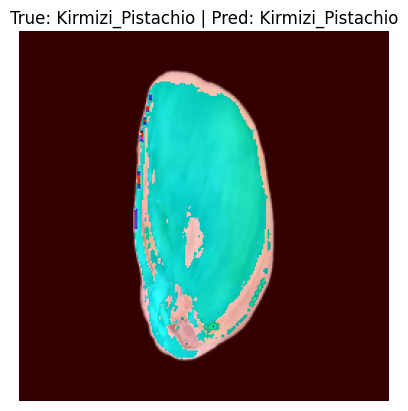

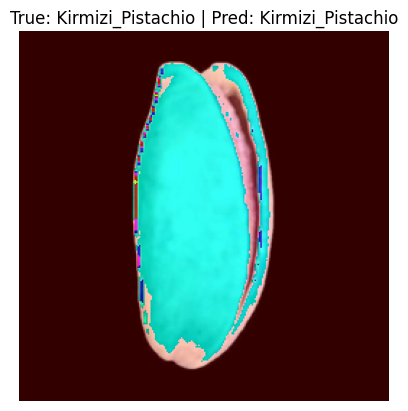

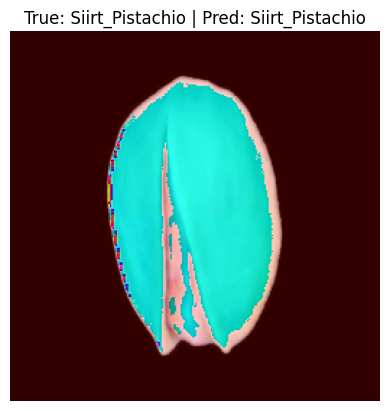

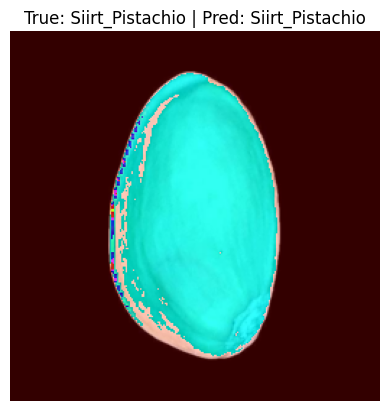

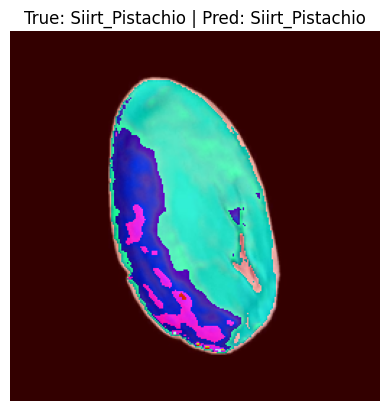

In [21]:
#Visualizing GradCAM Results


def show_gradcam(image_tensor, heatmap, true_label, pred_label, class_names):
    # Denormalize
    img = image_tensor.cpu().permute(1, 2, 0)
    img = img * torch.tensor([0.125, 0.125, 0.125]) + torch.tensor([0.5, 0.5, 0.5])
    img = img.numpy()

    heatmap = cv2.resize(heatmap, (img.shape[1], img.shape[0]))
    heatmap = np.uint8(255 * heatmap)
    heatmap = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET)

    superimposed_img = heatmap * 0.4 + img * 255

    plt.imshow(superimposed_img.astype(np.uint8))
    plt.title(f"True: {class_names[true_label]} | Pred: {class_names[pred_label]}")
    plt.axis('off')
    plt.show()

# GradCAM Setup
gradcam = GradCAM(model, target_layer=model.conv2)

# Visualize GradCAM for a few test samples
model.eval()
for images, labels in test_loader:
    images = images.to(device)
    labels = labels.to(device)

    outputs = model(images)
    _, preds = torch.max(outputs, 1)

    for idx in range(5):  # Show 5 examples
        input_tensor = images[idx].unsqueeze(0)
        heatmap, _ = gradcam.generate(input_tensor, class_idx=preds[idx].item())
        show_gradcam(images[idx], heatmap, labels[idx].item(), preds[idx].item(), dataset.class_names)
    break  # Only first batch